# CIL3090: Smart Infrastructure Engineering
## Course Project — ANN-Based Prediction of Concrete Compressive Strength
### Group Members-
## Devansh Verma(B23CI1014)
## Ramprakash(B23CI1031)

## Section 1 — Import Libraries and Load Dataset

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop
from tensorflow.keras.optimizers.schedules import (
    ExponentialDecay, CosineDecay, PiecewiseConstantDecay
)

import itertools, time

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

TensorFlow version : 2.19.0
Keras version      : 3.13.2


In [2]:
# Load dataset
df_raw = pd.read_excel('/content/Concrete_Data.xlsx')

# Rename columns for readability
COLUMN_MAP = {
    df_raw.columns[0]: 'Cement',
    df_raw.columns[1]: 'Blast_Furnace_Slag',
    df_raw.columns[2]: 'Fly_Ash',
    df_raw.columns[3]: 'Water',
    df_raw.columns[4]: 'Superplasticizer',
    df_raw.columns[5]: 'Coarse_Aggregate',
    df_raw.columns[6]: 'Fine_Aggregate',
    df_raw.columns[7]: 'Age',
    df_raw.columns[8]: 'Compressive_Strength'
}
df = df_raw.rename(columns=COLUMN_MAP)

print(f"Dataset shape : {df.shape}")
df.head()

Dataset shape : (1030, 9)


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Section 2 — Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Descriptive Statistics ===")
df.describe().T.round(3)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cement                1030 non-null   float64
 1   Blast_Furnace_Slag    1030 non-null   float64
 2   Fly_Ash               1030 non-null   float64
 3   Water                 1030 non-null   float64
 4   Superplasticizer      1030 non-null   float64
 5   Coarse_Aggregate      1030 non-null   float64
 6   Fine_Aggregate        1030 non-null   float64
 7   Age                   1030 non-null   int64  
 8   Compressive_Strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

=== Missing Values ===
Cement                  0
Blast_Furnace_Slag      0
Fly_Ash                 0
Water                   0
Superplasticizer        0
Coarse_Aggregate        0
Fine_Aggregate          0
Age                     0
Compressive_Strength    0
dty

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.166,104.507,102.000,192.375,272.900,350.000,540.000
Blast_Furnace_Slag,1030.0,73.895,86.279,0.000,0.000,22.000,142.950,359.400
Fly_Ash,1030.0,54.187,63.996,0.000,0.000,0.000,118.270,200.100
Water,1030.0,181.566,21.356,121.750,164.900,185.000,192.000,247.000
Superplasticizer,1030.0,6.203,5.973,0.000,0.000,6.350,10.160,32.200
Coarse_Aggregate,1030.0,972.919,77.754,801.000,932.000,968.000,1029.400,1145.000
Fine_Aggregate,1030.0,773.579,80.175,594.000,730.950,779.510,824.000,992.600
Age,1030.0,45.662,63.170,1.000,7.000,28.000,56.000,365.000
Compressive_Strength,1030.0,35.818,16.706,2.332,23.707,34.443,46.136,82.599


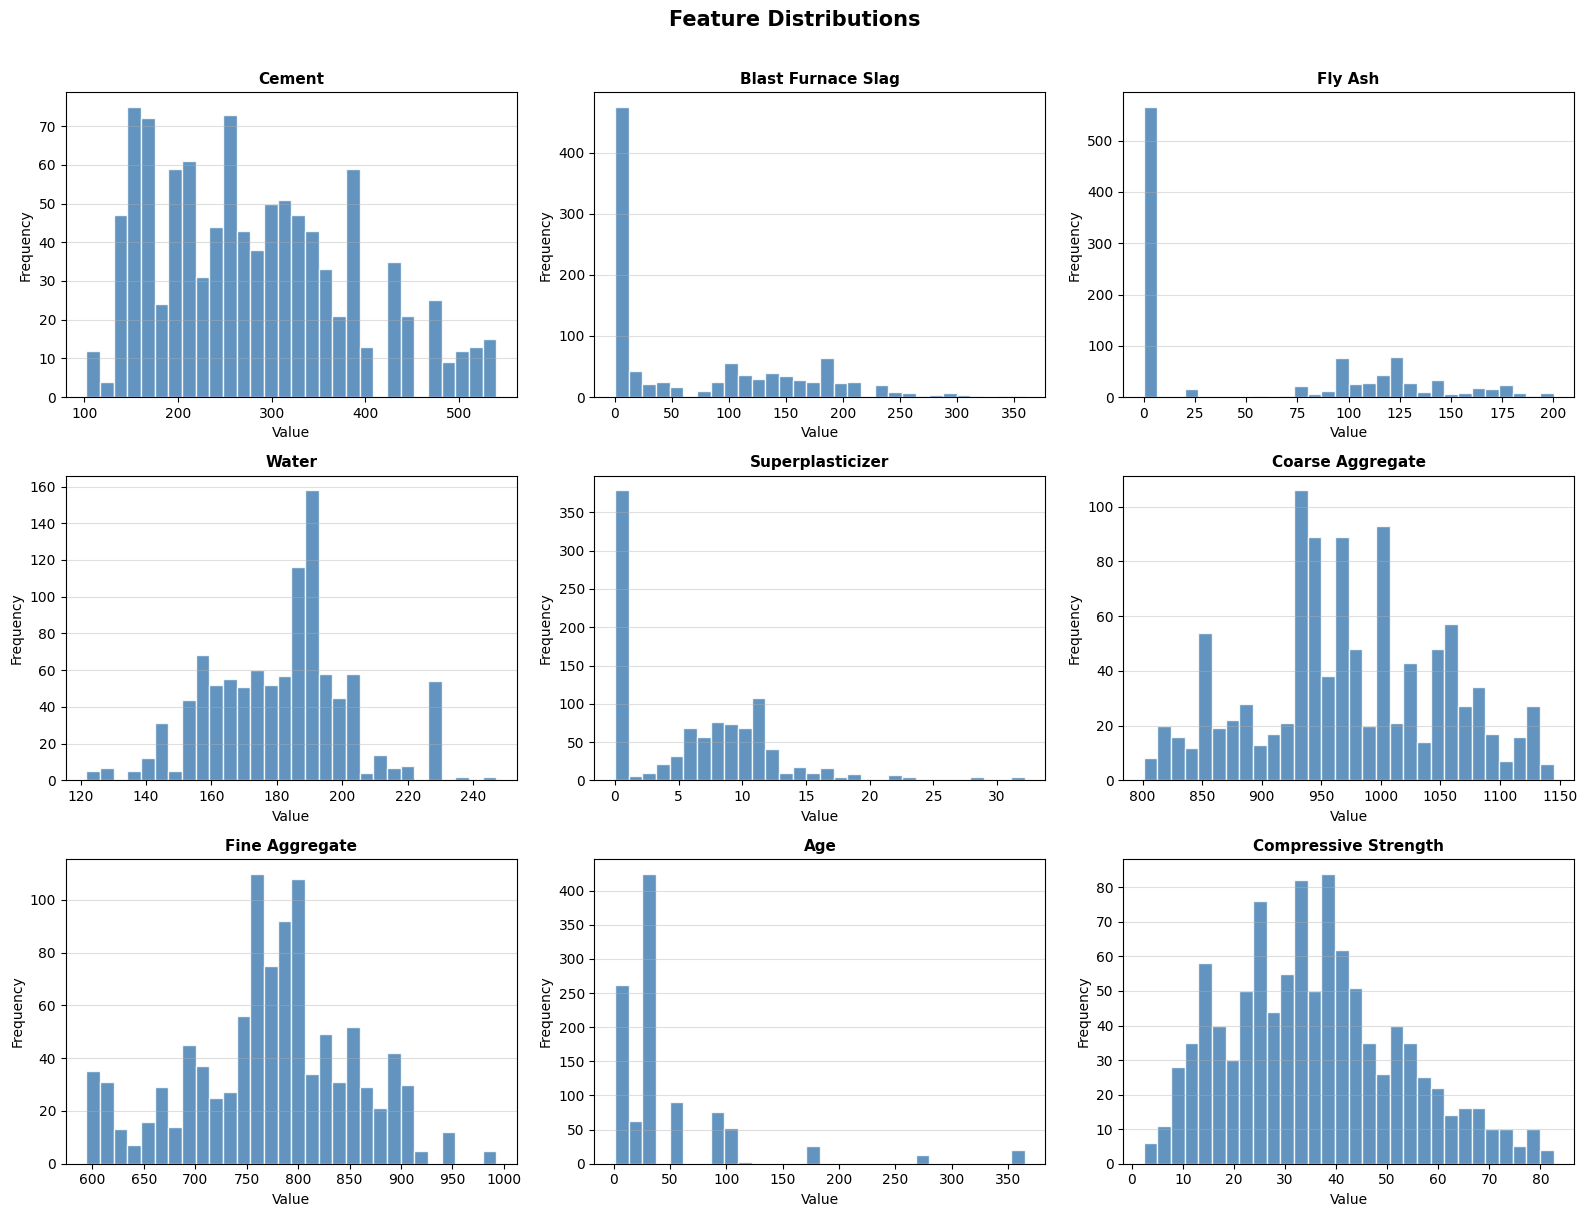

In [4]:
# Distribution of all features
FEATURES = [c for c in df.columns if c != 'Compressive_Strength']
TARGET   = 'Compressive_Strength'

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
all_cols = FEATURES + [TARGET]

for i, col in enumerate(all_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

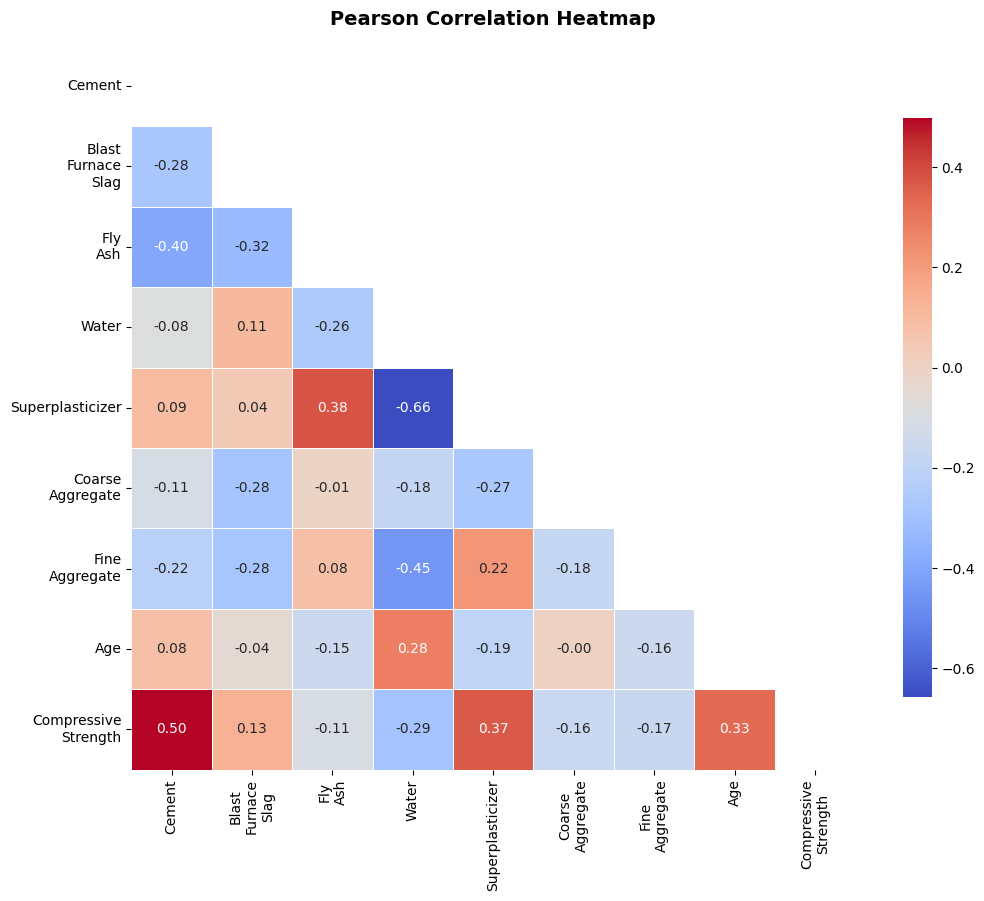

In [5]:
# Correlation heatmap
plt.figure(figsize=(11, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8},
    xticklabels=[c.replace('_', '\n') for c in corr.columns],
    yticklabels=[c.replace('_', '\n') for c in corr.columns]
)
plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

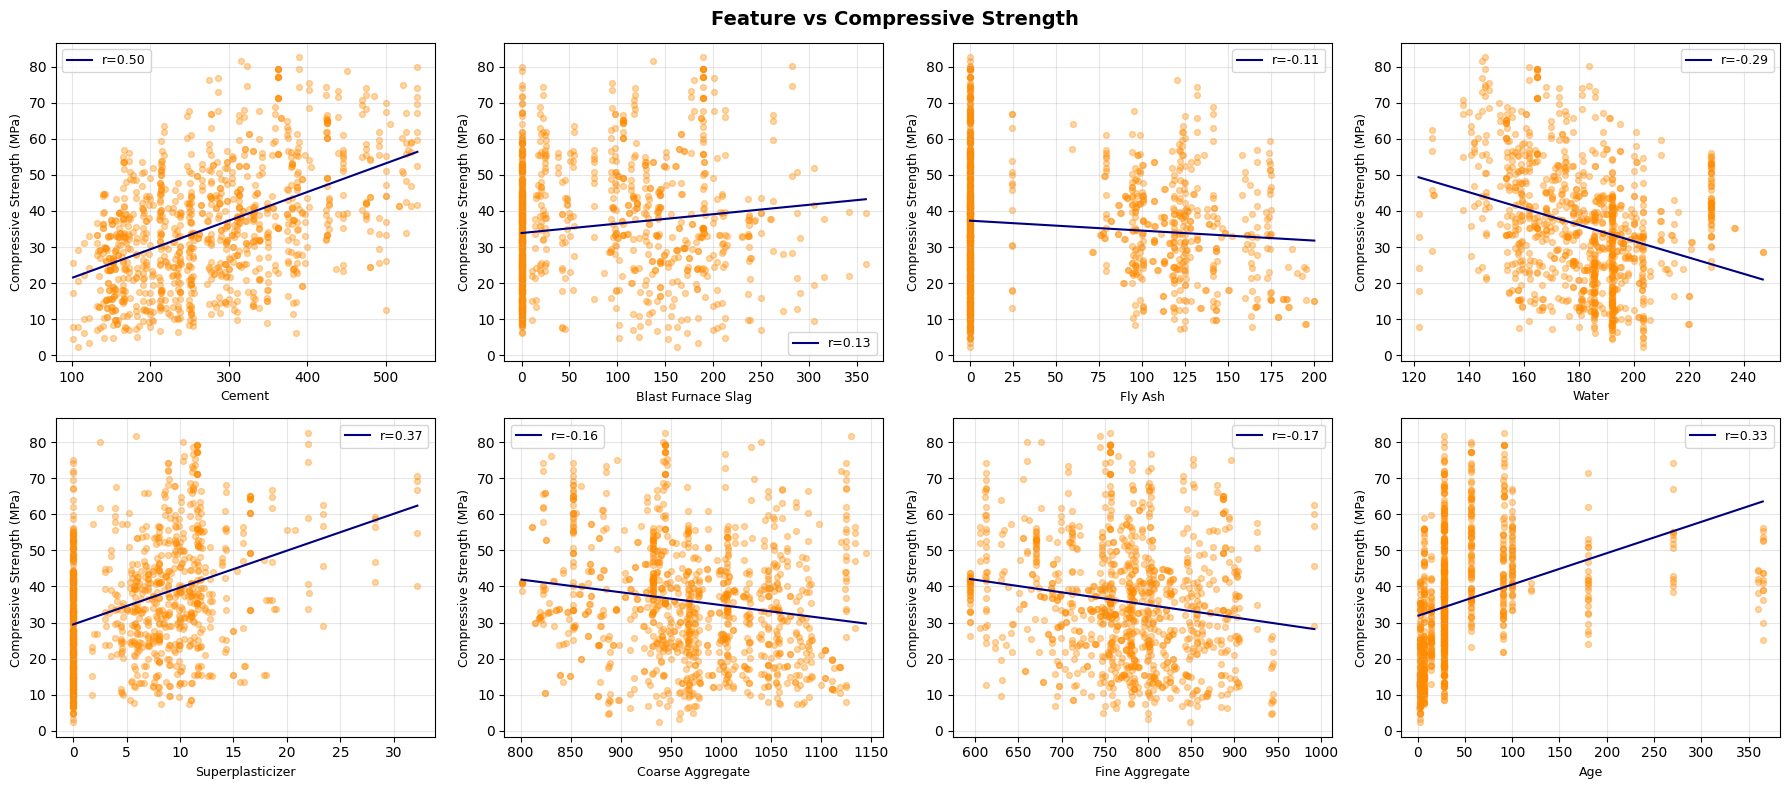

In [6]:
# Scatter: each feature vs target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].scatter(df[feat], df[TARGET], alpha=0.35, s=18, color='darkorange')
    m, b = np.polyfit(df[feat], df[TARGET], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='navy', linewidth=1.5, label=f'r={corr[feat][TARGET]:.2f}')
    axes[i].set_xlabel(feat.replace('_', ' '), fontsize=9)
    axes[i].set_ylabel('Compressive Strength (MPa)', fontsize=9)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Feature vs Compressive Strength', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

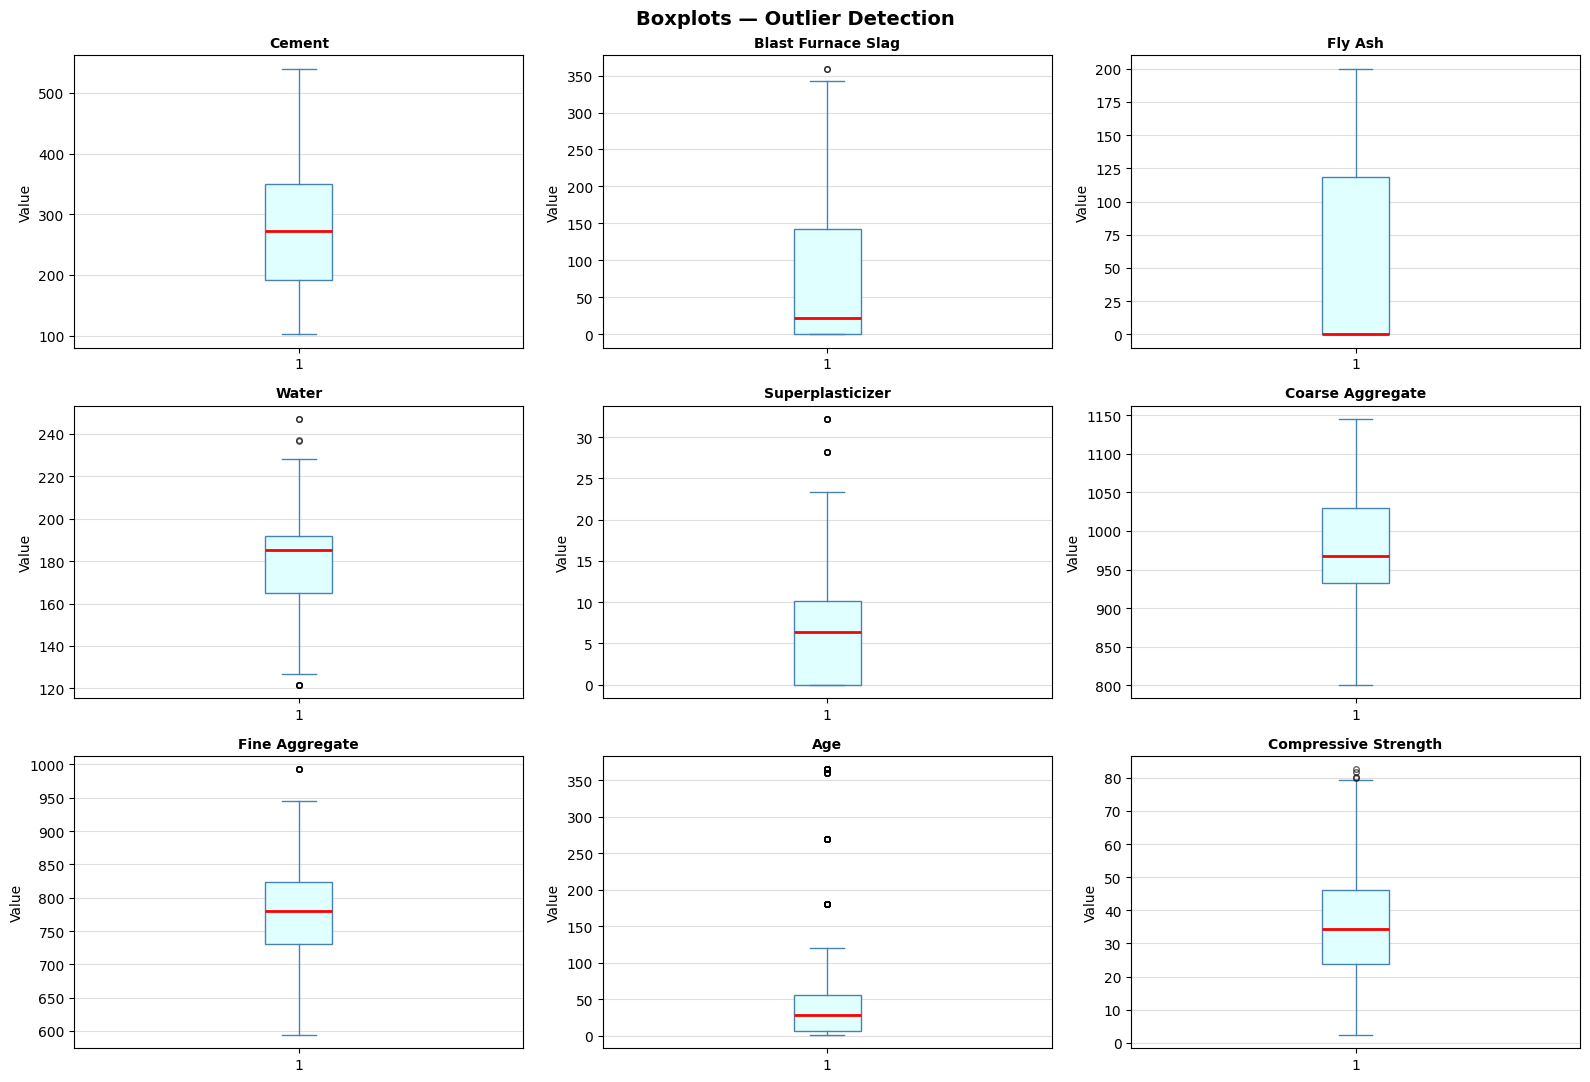

In [7]:
# Boxplots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightcyan', color='steelblue'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='steelblue'),
                    capprops=dict(color='steelblue'),
                    flierprops=dict(marker='o', color='orange', markersize=4, alpha=0.6))
    axes[i].set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Data Preprocessing

In [8]:
# Separate features and target
X = df[FEATURES].values
y = df[TARGET].values

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")

Training set   : 721 samples
Validation set : 154 samples
Test set       : 155 samples


In [9]:
# Standardise features (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Feature means (train, after scaling)  :", X_train_sc.mean(axis=0).round(4))
print("Feature stds  (train, after scaling)  :", X_train_sc.std(axis=0).round(4))

Feature means (train, after scaling)  : [ 0. -0. -0.  0.  0. -0.  0.  0.]
Feature stds  (train, after scaling)  : [1. 1. 1. 1. 1. 1. 1. 1.]


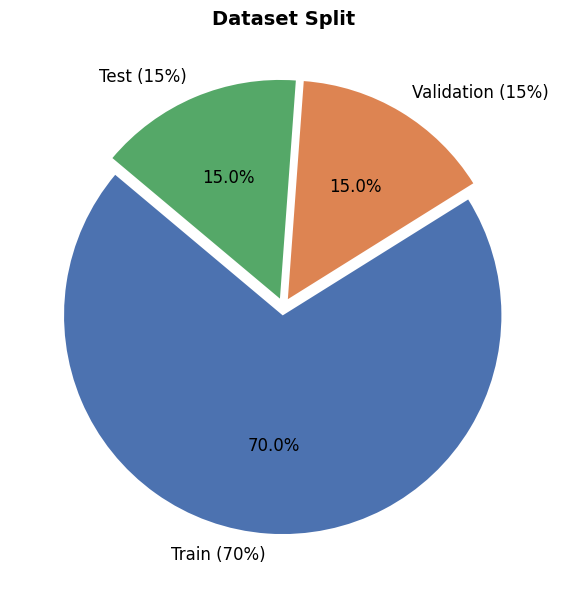

In [10]:
# Split summary pie chart
labels  = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
sizes   = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
colors  = ['#4C72B0', '#DD8452', '#55A868']
explode = [0.04, 0.04, 0.04]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title('Dataset Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_split.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Baseline ANN Model

In [11]:
# Helper: evaluation metrics
def evaluate_model(model, X, y, label='Set'):
    y_pred = model.predict(X, verbose=0).flatten()
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)
    print(f"[{label}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return rmse, mae, r2, y_pred

In [12]:
# Build baseline model
def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=(8,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

baseline_model = build_baseline()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train baseline
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

baseline_history = baseline_model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=300, batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print(f"Training stopped at epoch {len(baseline_history.history['loss'])}")

Training stopped at epoch 300


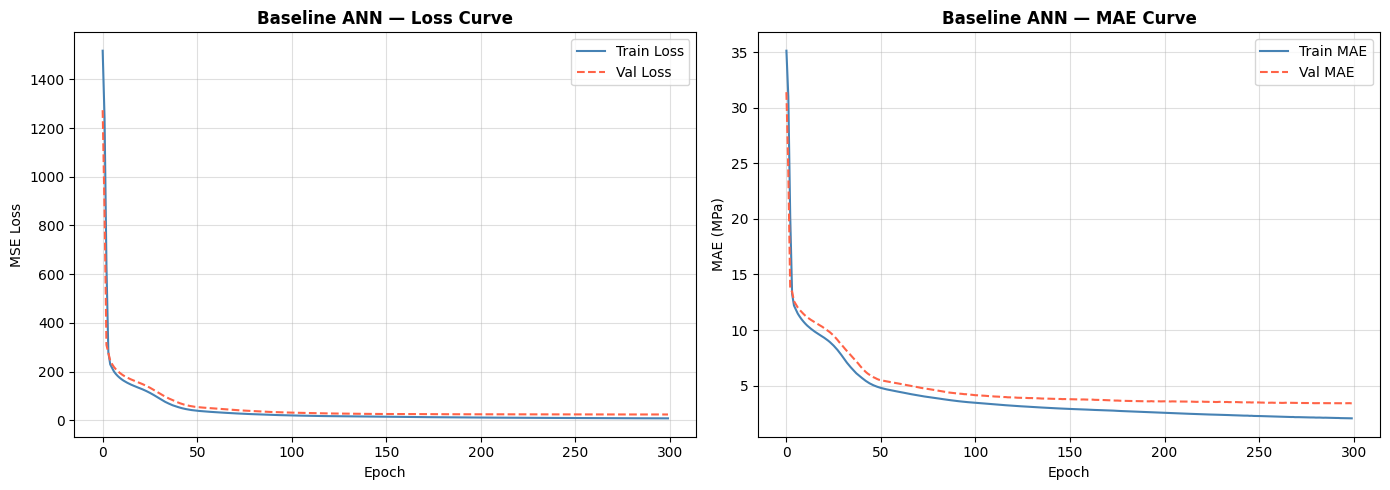

In [14]:
# Plot training curves
def plot_training(history, title='Baseline'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train Loss',  color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
    axes[0].set_title(f'{title} — Loss Curve', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.4)

    axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
    axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato', linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (MPa)')
    axes[1].set_title(f'{title} — MAE Curve', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training(baseline_history, 'Baseline ANN')

In [15]:
# Baseline performance
print("── Baseline Model Performance ──")
b_rmse_tr, b_mae_tr, b_r2_tr, _ = evaluate_model(baseline_model, X_train_sc, y_train, 'Train')
b_rmse_v,  b_mae_v,  b_r2_v,  _ = evaluate_model(baseline_model, X_val_sc,   y_val,   'Val')
b_rmse_ts, b_mae_ts, b_r2_ts, b_pred = evaluate_model(baseline_model, X_test_sc, y_test, 'Test')

── Baseline Model Performance ──
[Train]  RMSE=2.9444  MAE=2.1297  R²=0.9693
[Val]  RMSE=4.9119  MAE=3.4073  R²=0.9163
[Test]  RMSE=6.1415  MAE=4.3699  R²=0.8493


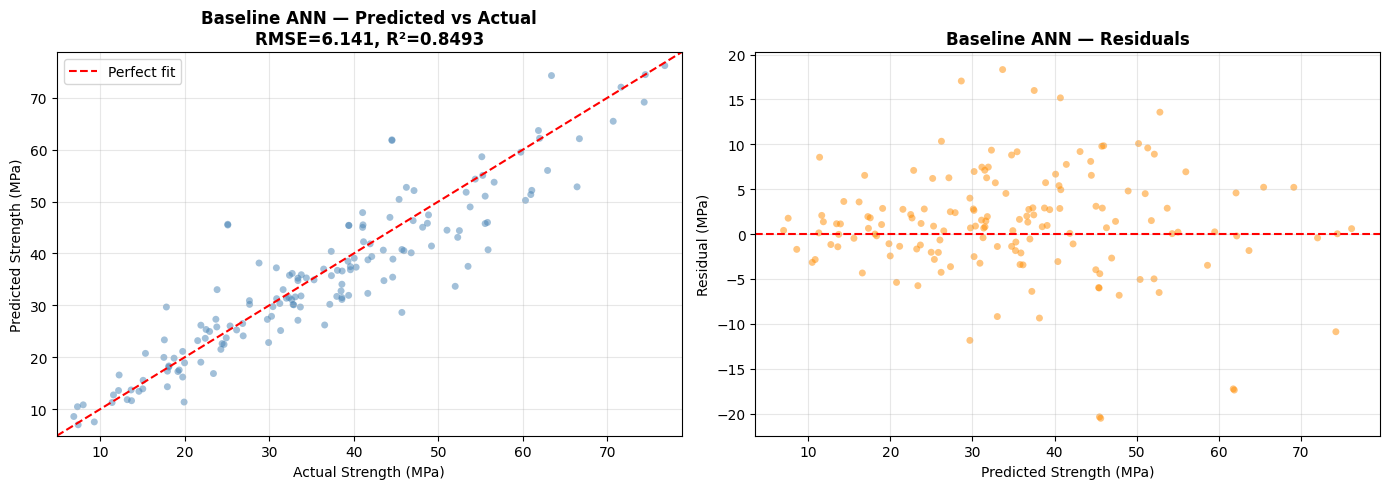

In [16]:
# Predicted vs Actual — Baseline
def plot_pred_vs_actual(y_true, y_pred, title='Baseline', rmse=None, r2=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    lims = [min(y_true.min(), y_pred.min())-2, max(y_true.max(), y_pred.max())+2]
    axes[0].scatter(y_true, y_pred, alpha=0.5, s=25, color='steelblue', edgecolors='none')
    axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    axes[0].set_xlim(lims); axes[0].set_ylim(lims)
    axes[0].set_xlabel('Actual Strength (MPa)')
    axes[0].set_ylabel('Predicted Strength (MPa)')
    axes[0].set_title(f'{title} — Predicted vs Actual\nRMSE={rmse:.3f}, R²={r2:.4f}', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.5, s=25, color='darkorange', edgecolors='none')
    axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Predicted Strength (MPa)')
    axes[1].set_ylabel('Residual (MPa)')
    axes[1].set_title(f'{title} — Residuals', fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_pred_vs_actual.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_pred_vs_actual(y_test, b_pred, 'Baseline ANN', b_rmse_ts, b_r2_ts)

## Section 5 — Hyperparameter Optimization

In [17]:
# 5A: Effect of Activation Functions
ACTIVATIONS = ['relu', 'sigmoid', 'tanh']
act_results  = {}

for act in ACTIVATIONS:
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(8,)),
        layers.Dense(64, activation=act),
        layers.Dense(64, activation=act),
        layers.Dense(32, activation=act),
        layers.Dense(1,  activation='linear')
    ])
    m.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    hist = m.fit(X_train_sc, y_train,
                 validation_data=(X_val_sc, y_val),
                 epochs=200, batch_size=32,
                 callbacks=[EarlyStopping(patience=25, restore_best_weights=True)],
                 verbose=0)
    y_pred = m.predict(X_test_sc, verbose=0).flatten()
    act_results[act] = {
        'history': hist,
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae':  mean_absolute_error(y_test, y_pred),
        'r2':   r2_score(y_test, y_pred)
    }
    print(f"{act:8s} → RMSE={act_results[act]['rmse']:.3f}  R²={act_results[act]['r2']:.4f}")

relu     → RMSE=6.262  R²=0.8433


sigmoid  → RMSE=15.983  R²=-0.0206


tanh     → RMSE=5.599  R²=0.8747


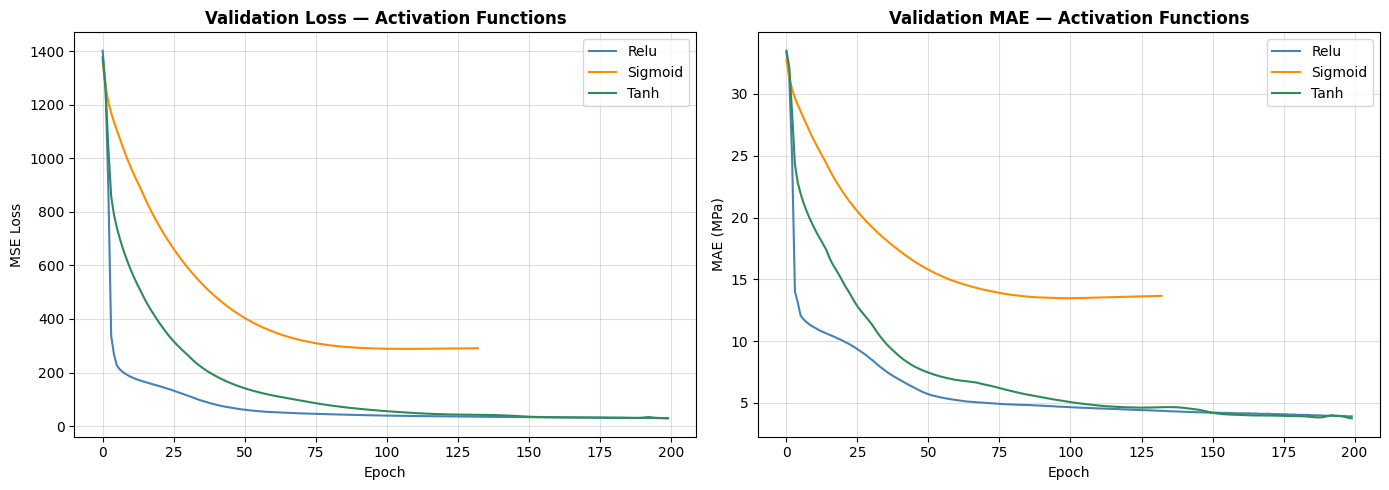

In [18]:
# Plot: activation comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_act = {'relu': 'steelblue', 'sigmoid': 'darkorange', 'tanh': 'seagreen'}

for act, res in act_results.items():
    axes[0].plot(res['history'].history['val_loss'], label=act.capitalize(), color=colors_act[act])
    axes[1].plot(res['history'].history['val_mae'],  label=act.capitalize(), color=colors_act[act])

axes[0].set_title('Validation Loss — Activation Functions', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)
axes[1].set_title('Validation MAE — Activation Functions', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (MPa)'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# 5B: Effect of Optimizers
OPTIMIZERS = {
    'SGD+Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'AdaGrad':      Adagrad(learning_rate=0.01),
    'RMSprop':      RMSprop(learning_rate=0.001)
}
opt_results = {}

for name, opt in OPTIMIZERS.items():
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(8,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='linear')
    ])
    m.compile(optimizer=opt, loss='mse', metrics=['mae'])
    hist = m.fit(X_train_sc, y_train,
                 validation_data=(X_val_sc, y_val),
                 epochs=200, batch_size=32,
                 callbacks=[EarlyStopping(patience=25, restore_best_weights=True)],
                 verbose=0)
    y_pred = m.predict(X_test_sc, verbose=0).flatten()

    # Handle cases where y_pred might contain NaN values
    if np.isnan(y_pred).any():
        rmse = np.nan
        mae  = np.nan
        r2   = np.nan
        print(f"{name:15s} → Training diverged or produced NaN predictions.")
    else:
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)
        print(f"{name:15s} → RMSE={rmse:.3f}  R²={r2:.4f}")

    opt_results[name] = {
        'history': hist,
        'rmse': rmse,
        'mae':  mae,
        'r2':   r2
    }

SGD+Momentum    → RMSE=16.076  R²=-0.0326
AdaGrad         → RMSE=6.198  R²=0.8465
RMSprop         → RMSE=5.722  R²=0.8692


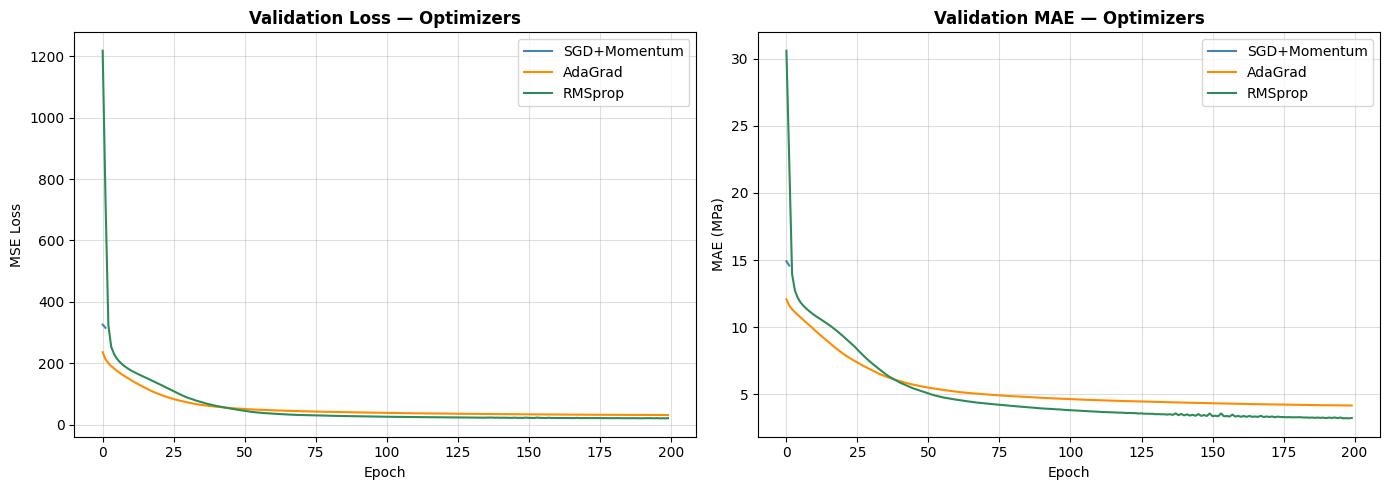

In [20]:
# Plot: optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_opt = {'SGD+Momentum': 'steelblue', 'AdaGrad': 'darkorange', 'RMSprop': 'seagreen'}

for name, res in opt_results.items():
    axes[0].plot(res['history'].history['val_loss'], label=name, color=colors_opt[name])
    axes[1].plot(res['history'].history['val_mae'],  label=name, color=colors_opt[name])

axes[0].set_title('Validation Loss — Optimizers', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)
axes[1].set_title('Validation MAE — Optimizers', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (MPa)'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# 5C: Effect of Learning Rate Schedules
STEPS_PER_EPOCH = int(np.ceil(X_train_sc.shape[0] / 32))

LR_SCHEDULES = {
    'Step Decay':         PiecewiseConstantDecay(
                              boundaries=[STEPS_PER_EPOCH*50, STEPS_PER_EPOCH*100],
                              values=[1e-3, 5e-4, 1e-4]),
    'Exponential Decay':  ExponentialDecay(
                              initial_learning_rate=1e-3,
                              decay_steps=STEPS_PER_EPOCH*10,
                              decay_rate=0.9),
    'Cosine Annealing':   CosineDecay(
                              initial_learning_rate=1e-3,
                              decay_steps=STEPS_PER_EPOCH*200)
}
lr_results = {}

for name, schedule in LR_SCHEDULES.items():
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(8,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='linear')
    ])
    m.compile(optimizer=Adam(learning_rate=schedule), loss='mse', metrics=['mae'])
    hist = m.fit(X_train_sc, y_train,
                 validation_data=(X_val_sc, y_val),
                 epochs=200, batch_size=32,
                 callbacks=[EarlyStopping(patience=25, restore_best_weights=True)],
                 verbose=0)
    y_pred = m.predict(X_test_sc, verbose=0).flatten()
    lr_results[name] = {
        'history': hist,
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae':  mean_absolute_error(y_test, y_pred),
        'r2':   r2_score(y_test, y_pred)
    }
    print(f"{name:20s} → RMSE={lr_results[name]['rmse']:.3f}  R²={lr_results[name]['r2']:.4f}")

Step Decay           → RMSE=6.381  R²=0.8373
Exponential Decay    → RMSE=6.324  R²=0.8402
Cosine Annealing     → RMSE=6.402  R²=0.8363


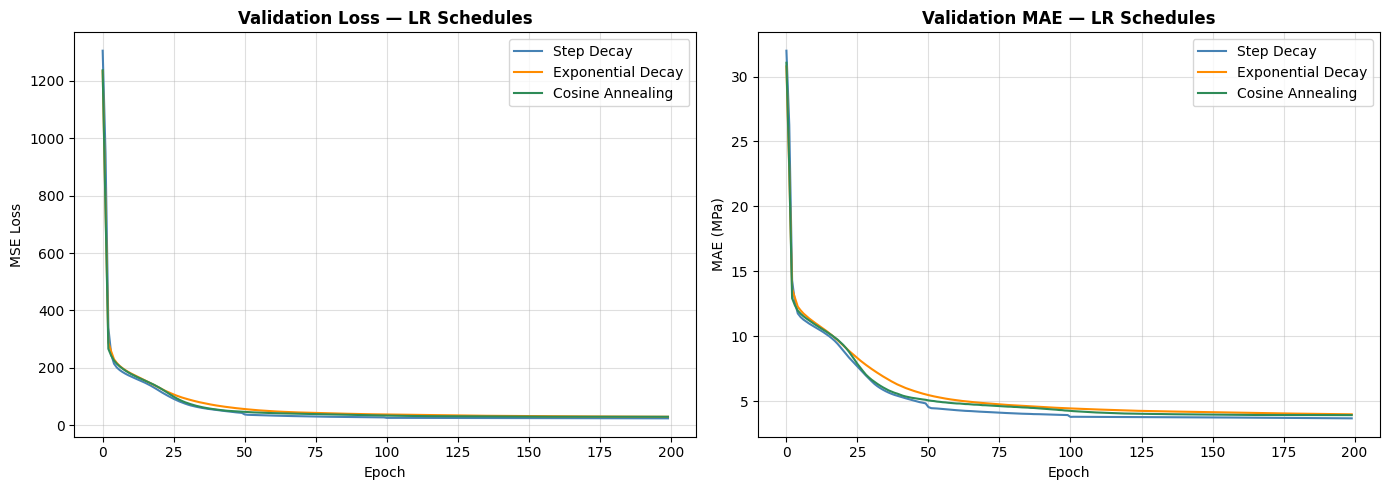

In [22]:
# Plot: LR schedule comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_lr = {'Step Decay': 'steelblue', 'Exponential Decay': 'darkorange', 'Cosine Annealing': 'seagreen'}

for name, res in lr_results.items():
    axes[0].plot(res['history'].history['val_loss'], label=name, color=colors_lr[name])
    axes[1].plot(res['history'].history['val_mae'],  label=name, color=colors_lr[name])

axes[0].set_title('Validation Loss — LR Schedules', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)
axes[1].set_title('Validation MAE — LR Schedules', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (MPa)'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# 5D: Effect of Network Architecture (layers × neurons)
ARCHITECTURES = {
    'Shallow-Small  [1×32]':    [32],
    'Shallow-Medium [1×64]':    [64],
    'Deep-Small     [3×32]':    [32, 32, 32],
    'Deep-Medium    [3×64]':    [64, 64, 64],
    'Wide-Deep      [4×128]':   [128, 128, 64, 32],
    'Very-Deep      [5×64]':    [64, 64, 64, 64, 32]
}
arch_results = {}

for name, units in ARCHITECTURES.items():
    tf.random.set_seed(SEED)
    layers_list = [layers.Input(shape=(8,))]
    for u in units:
        layers_list.append(layers.Dense(u, activation='relu'))
    layers_list.append(layers.Dense(1, activation='linear'))
    m = keras.Sequential(layers_list)
    m.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    hist = m.fit(X_train_sc, y_train,
                 validation_data=(X_val_sc, y_val),
                 epochs=200, batch_size=32,
                 callbacks=[EarlyStopping(patience=25, restore_best_weights=True)],
                 verbose=0)
    y_pred = m.predict(X_test_sc, verbose=0).flatten()
    arch_results[name] = {
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae':  mean_absolute_error(y_test, y_pred),
        'r2':   r2_score(y_test, y_pred),
        'params': m.count_params()
    }
    print(f"{name} → RMSE={arch_results[name]['rmse']:.3f}  R²={arch_results[name]['r2']:.4f}  Params={arch_results[name]['params']}")

Shallow-Small  [1×32] → RMSE=7.281  R²=0.7882  Params=321
Shallow-Medium [1×64] → RMSE=6.542  R²=0.8290  Params=641
Deep-Small     [3×32] → RMSE=6.022  R²=0.8551  Params=2433
Deep-Medium    [3×64] → RMSE=5.785  R²=0.8663  Params=8961
Wide-Deep      [4×128] → RMSE=6.248  R²=0.8440  Params=28033
Very-Deep      [5×64] → RMSE=6.544  R²=0.8289  Params=15169


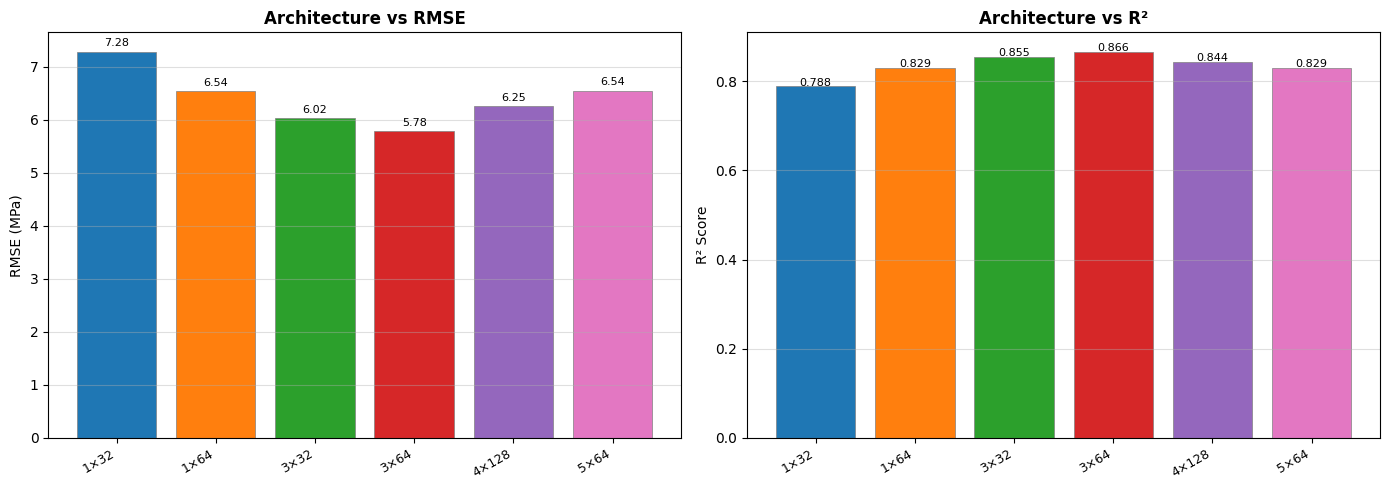

In [24]:
# Plot: architecture comparison
arch_names = list(arch_results.keys())
arch_rmse  = [arch_results[k]['rmse'] for k in arch_names]
arch_r2    = [arch_results[k]['r2']   for k in arch_names]
short_names = [n.split('[')[1].rstrip(']') for n in arch_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(arch_names))
palette = plt.cm.tab10(np.linspace(0, 0.6, len(arch_names)))

bars1 = axes[0].bar(x, arch_rmse, color=palette, edgecolor='grey', linewidth=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('RMSE (MPa)'); axes[0].set_title('Architecture vs RMSE', fontweight='bold'); axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars1, arch_rmse):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{val:.2f}', ha='center', fontsize=8)

bars2 = axes[1].bar(x, arch_r2, color=palette, edgecolor='grey', linewidth=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('R² Score'); axes[1].set_title('Architecture vs R²', fontweight='bold'); axes[1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, arch_r2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# 5E: Effect of Batch Size
BATCH_SIZES   = [16, 32, 64, 128]
batch_results = {}

for bs in BATCH_SIZES:
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(8,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='linear')
    ])
    m.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    hist = m.fit(X_train_sc, y_train,
                 validation_data=(X_val_sc, y_val),
                 epochs=200, batch_size=bs,
                 callbacks=[EarlyStopping(patience=25, restore_best_weights=True)],
                 verbose=0)
    y_pred = m.predict(X_test_sc, verbose=0).flatten()
    batch_results[bs] = {
        'history': hist,
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae':  mean_absolute_error(y_test, y_pred),
        'r2':   r2_score(y_test, y_pred)
    }
    print(f"Batch={bs:3d} → RMSE={batch_results[bs]['rmse']:.3f}  R²={batch_results[bs]['r2']:.4f}")

Batch= 16 → RMSE=6.041  R²=0.8542
Batch= 32 → RMSE=6.205  R²=0.8462
Batch= 64 → RMSE=5.887  R²=0.8615
Batch=128 → RMSE=6.106  R²=0.8510


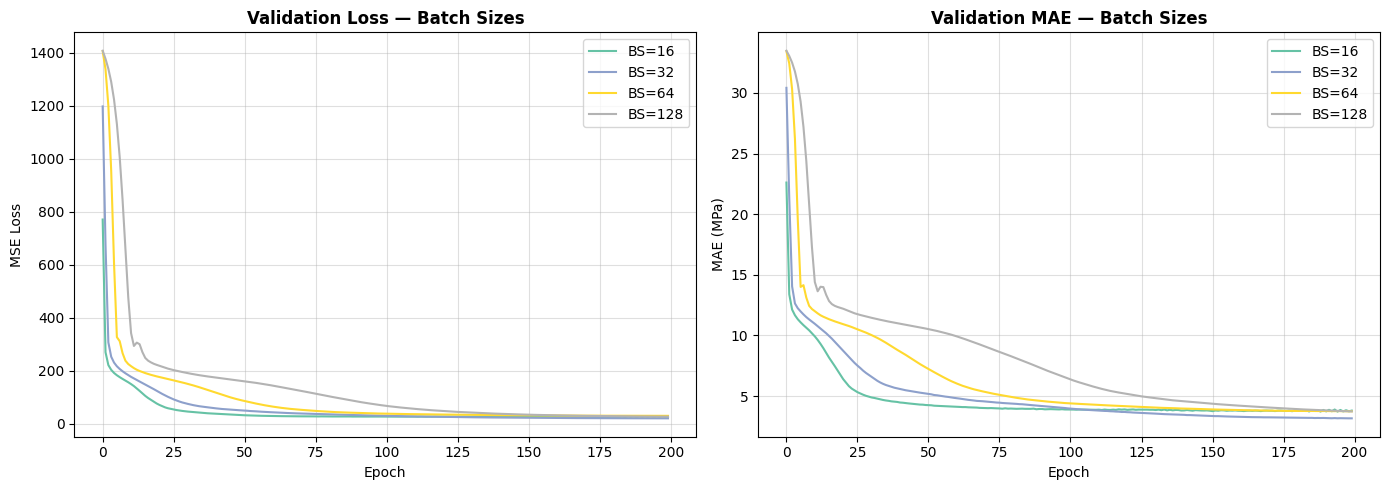

In [26]:
# Plot: batch size comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_colors = plt.cm.Set2(np.linspace(0, 1, len(BATCH_SIZES)))

for bs, clr in zip(BATCH_SIZES, bs_colors):
    axes[0].plot(batch_results[bs]['history'].history['val_loss'], label=f'BS={bs}', color=clr)
    axes[1].plot(batch_results[bs]['history'].history['val_mae'],  label=f'BS={bs}', color=clr)

axes[0].set_title('Validation Loss — Batch Sizes', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)
axes[1].set_title('Validation MAE — Batch Sizes', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (MPa)'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('batch_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Model Evaluation & Comparison

In [27]:
# Compile all results into a comparison table
rows = []

rows.append({'Model': 'Baseline ANN (ReLU, Adam)',
             'RMSE': b_rmse_ts, 'MAE': b_mae_ts, 'R2': b_r2_ts})

for act, res in act_results.items():
    rows.append({'Model': f'Activation: {act.capitalize()}',
                 'RMSE': res['rmse'], 'MAE': res['mae'], 'R2': res['r2']})

for name, res in opt_results.items():
    rows.append({'Model': f'Optimizer: {name}',
                 'RMSE': res['rmse'], 'MAE': res['mae'], 'R2': res['r2']})

for name, res in lr_results.items():
    rows.append({'Model': f'LR Schedule: {name}',
                 'RMSE': res['rmse'], 'MAE': res['mae'], 'R2': res['r2']})

for bs, res in batch_results.items():
    rows.append({'Model': f'Batch Size: {bs}',
                 'RMSE': res['rmse'], 'MAE': res['mae'], 'R2': res['r2']})

comparison_df = pd.DataFrame(rows).round(4).sort_values('RMSE')
comparison_df.reset_index(drop=True, inplace=True)
print(comparison_df.to_string(index=False))

                         Model    RMSE     MAE      R2
              Activation: Tanh  5.5995  4.1722  0.8747
            Optimizer: RMSprop  5.7223  4.2928  0.8692
                Batch Size: 64  5.8871  4.4845  0.8615
                Batch Size: 16  6.0414  4.3767  0.8542
               Batch Size: 128  6.1064  4.6966  0.8510
     Baseline ANN (ReLU, Adam)  6.1415  4.3699  0.8493
            Optimizer: AdaGrad  6.1980  4.7785  0.8465
                Batch Size: 32  6.2049  4.4610  0.8462
              Activation: Relu  6.2622  4.9293  0.8433
LR Schedule: Exponential Decay  6.3241  4.7149  0.8402
       LR Schedule: Step Decay  6.3808  4.6572  0.8373
 LR Schedule: Cosine Annealing  6.4018  4.6988  0.8363
           Activation: Sigmoid 15.9826 12.8882 -0.0206
       Optimizer: SGD+Momentum 16.0764 13.0862 -0.0326


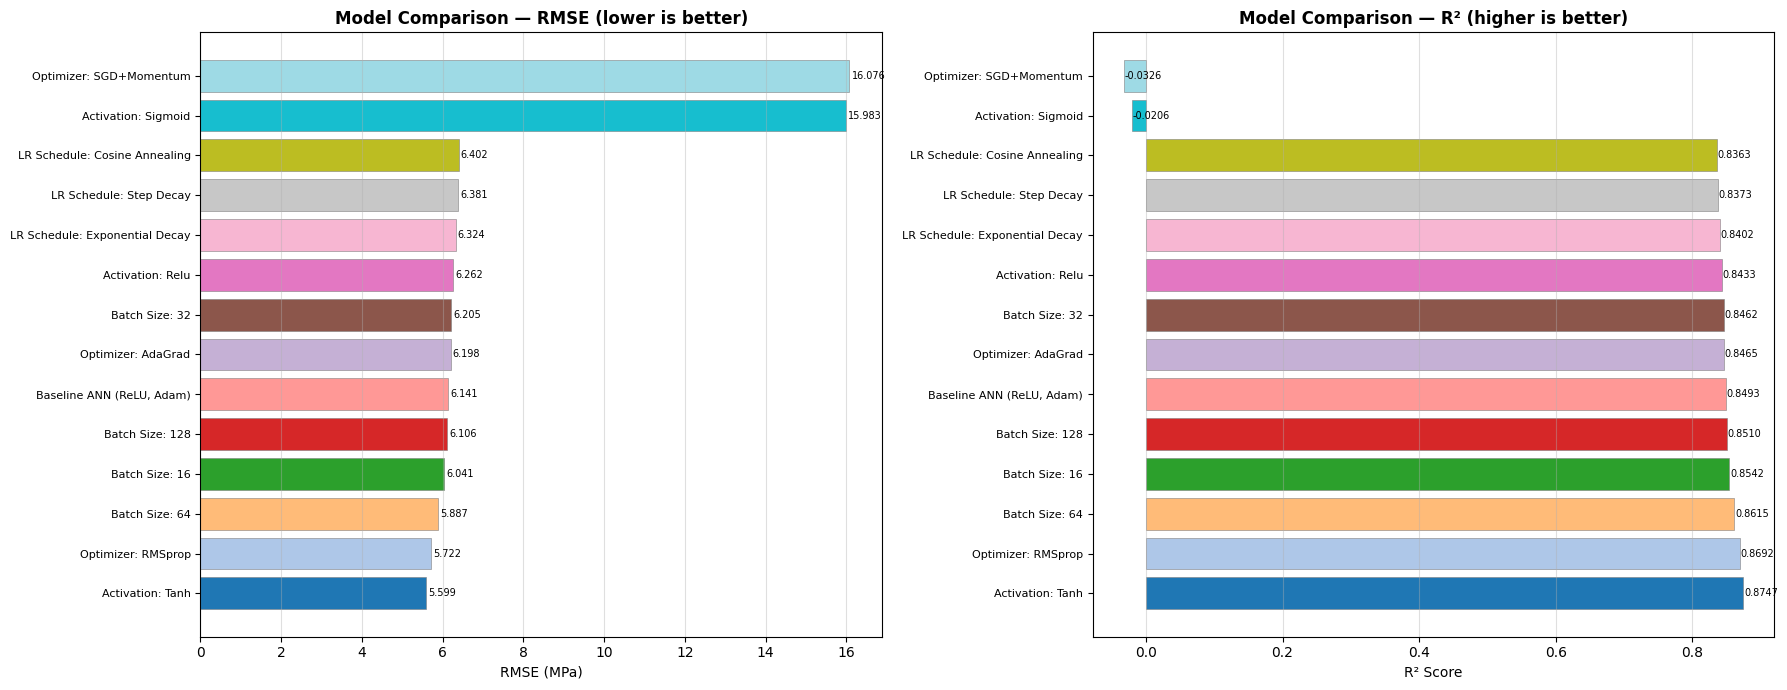

In [28]:
# Bar chart: all models by RMSE
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette_all = plt.cm.tab20(np.linspace(0, 1, len(comparison_df)))
labels_all  = comparison_df['Model'].tolist()
x_all = np.arange(len(labels_all))

b1 = axes[0].barh(x_all, comparison_df['RMSE'], color=palette_all, edgecolor='grey', linewidth=0.4)
axes[0].set_yticks(x_all); axes[0].set_yticklabels(labels_all, fontsize=8)
axes[0].set_xlabel('RMSE (MPa)'); axes[0].set_title('Model Comparison — RMSE (lower is better)', fontweight='bold')
axes[0].grid(axis='x', alpha=0.4)
for bar, val in zip(b1, comparison_df['RMSE']):
    axes[0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=7)

b2 = axes[1].barh(x_all, comparison_df['R2'], color=palette_all, edgecolor='grey', linewidth=0.4)
axes[1].set_yticks(x_all); axes[1].set_yticklabels(labels_all, fontsize=8)
axes[1].set_xlabel('R² Score'); axes[1].set_title('Model Comparison — R² (higher is better)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.4)
for bar, val in zip(b2, comparison_df['R2']):
    axes[1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Identify best config from experiments
best_act = min(act_results, key=lambda k: act_results[k]['rmse'])
best_opt = min(opt_results, key=lambda k: opt_results[k]['rmse'])
best_lr  = min(lr_results,  key=lambda k: lr_results[k]['rmse'])
best_bs  = min(batch_results, key=lambda k: batch_results[k]['rmse'])

print(f"Best Activation Function : {best_act}  (RMSE={act_results[best_act]['rmse']:.4f})")
print(f"Best Optimizer           : {best_opt}  (RMSE={opt_results[best_opt]['rmse']:.4f})")
print(f"Best LR Schedule         : {best_lr}  (RMSE={lr_results[best_lr]['rmse']:.4f})")
print(f"Best Batch Size          : {best_bs}   (RMSE={batch_results[best_bs]['rmse']:.4f})")

Best Activation Function : tanh  (RMSE=5.5995)
Best Optimizer           : RMSprop  (RMSE=5.7223)
Best LR Schedule         : Exponential Decay  (RMSE=6.3241)
Best Batch Size          : 64   (RMSE=5.8871)


## Section 7 — Final Optimized Model

In [30]:
# Build and train the final optimized model
# Best settings determined from experiments above:
# Architecture : 4 layers [128→64→64→32], ReLU + Batch Normalization + Dropout
# Optimizer    : Adam with Cosine Annealing LR schedule
# Batch size   : 16

FINAL_STEPS = int(np.ceil(X_train_sc.shape[0] / 16))
cosine_schedule = CosineDecay(initial_learning_rate=1e-3, decay_steps=FINAL_STEPS*300)

tf.random.set_seed(SEED)

final_model = keras.Sequential([
    layers.Input(shape=(8,)),

    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='linear')
], name='Optimized_ANN')

final_model.compile(
    optimizer=Adam(learning_rate=cosine_schedule),
    loss='mse',
    metrics=['mae']
)

final_model.summary()

Model: "Optimized_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_79 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,449 (64.25 KB)

 Trainable params: 16,065 (62.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [31]:
# Train final model
final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)
]

final_history = final_model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=400,
    batch_size=16,
    callbacks=final_callbacks,
    verbose=1
)
print(f"\nTraining stopped at epoch {len(final_history.history['loss'])}")

Epoch 1/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 1327.7054 - mae: 32.6906 - val_loss: 1232.8867 - val_mae: 31.1798
Epoch 2/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 472.4549 - mae: 17.6341 - val_loss: 621.2228 - val_mae: 20.7691
Epoch 3/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 144.5417 - mae: 9.3552 - val_loss: 444.8625 - val_mae: 16.9605
Epoch 4/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 111.8826 - mae: 8.2375 - val_loss: 307.4513 - val_mae: 13.7005
Epoch 5/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 88.8289 - mae: 7.3253 - val_loss: 216.6371 - val_mae: 11.3902
Epoch 6/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 87.1636 - mae: 7.1275 - val_loss: 166.6514 - val_mae: 9.9006
Epoch 7/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 77.5946 - mae: 6.7635 - val_loss: 127.4090 - val_mae: 8.5369
Epoch 8/400
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 76.4315 - mae: 6.7221 - val_loss: 106.0794 - val_mae: 7.8579
Epoch 9/400
46/46 ━━━━━━━━

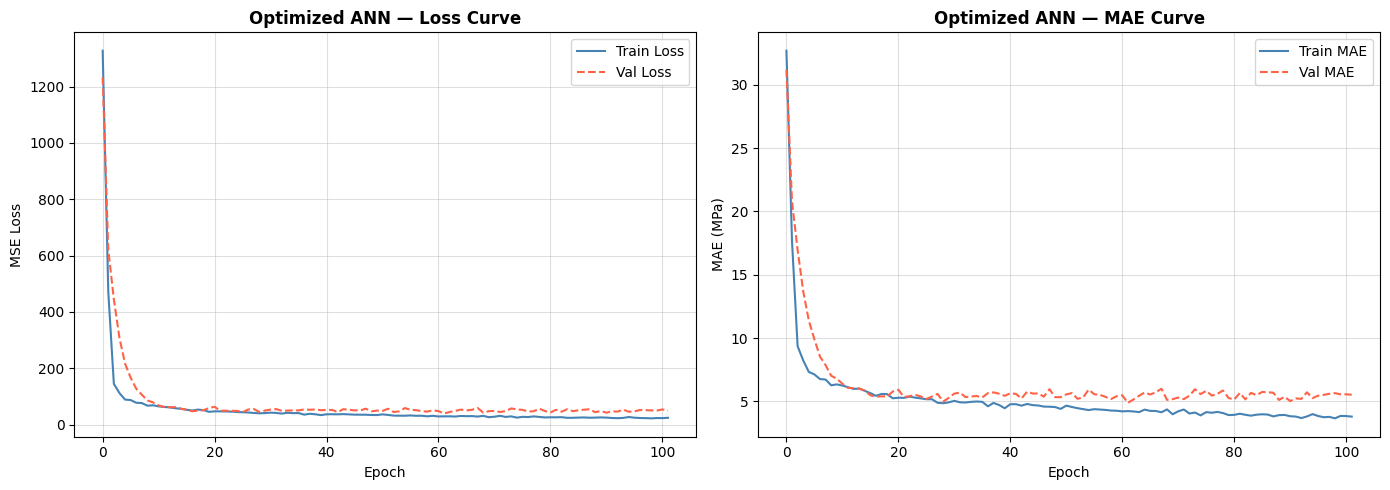

In [32]:
# Final model training curves
plot_training(final_history, 'Optimized ANN')

In [33]:
# Final model performance
print("FINAL OPTIMIZED MODEL RESULTS:")
f_rmse_tr, f_mae_tr, f_r2_tr, _ = evaluate_model(final_model, X_train_sc, y_train, 'Train')
f_rmse_v,  f_mae_v,  f_r2_v,  _ = evaluate_model(final_model, X_val_sc,   y_val,   'Val')
f_rmse_ts, f_mae_ts, f_r2_ts, f_pred = evaluate_model(final_model, X_test_sc, y_test, 'Test')

FINAL OPTIMIZED MODEL RESULTS:
[Train]  RMSE=5.0929  MAE=4.0813  R²=0.9080
[Val]  RMSE=6.2693  MAE=4.8831  R²=0.8637
[Test]  RMSE=6.7094  MAE=5.3557  R²=0.8201


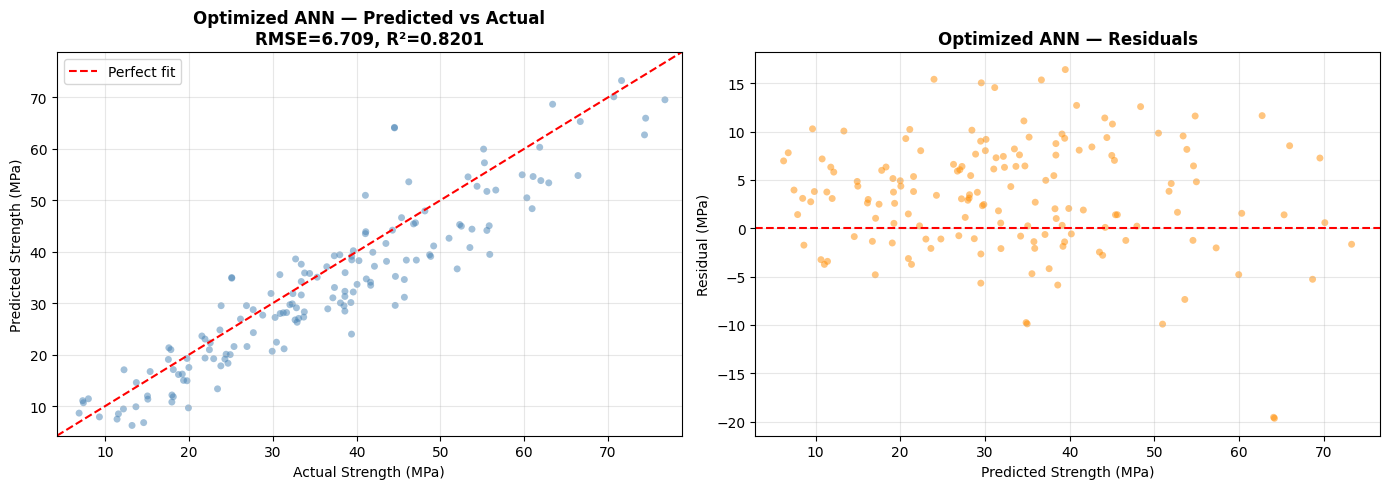

In [34]:
# Predicted vs Actual — Final Model
plot_pred_vs_actual(y_test, f_pred, 'Optimized ANN', f_rmse_ts, f_r2_ts)

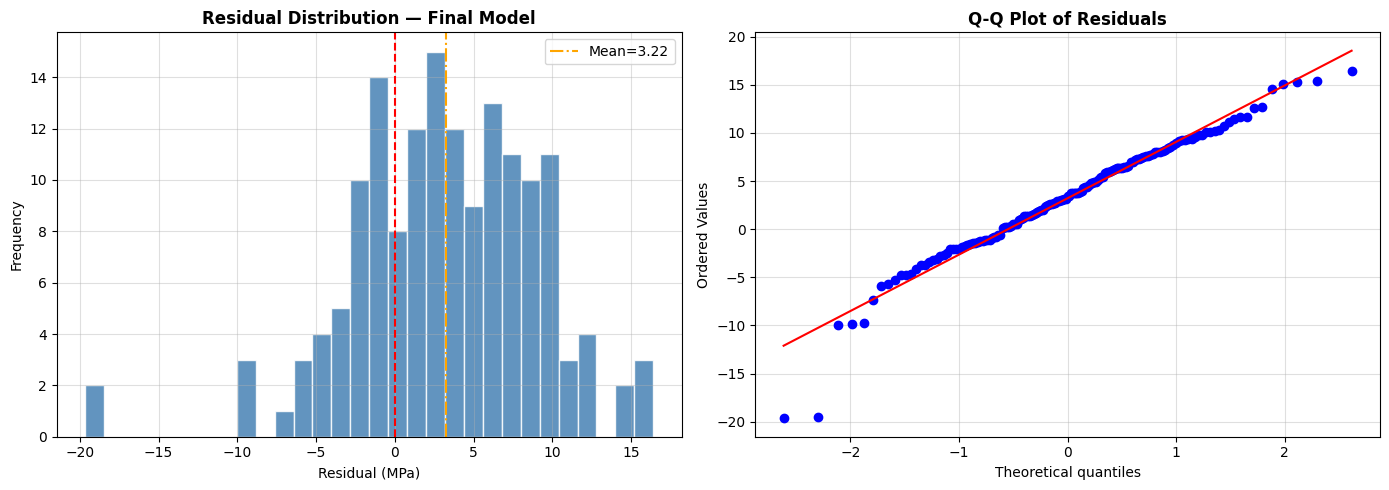

In [35]:
# Residual distribution
residuals_final = y_test - f_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_final, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].axvline(residuals_final.mean(), color='orange', linewidth=1.5, linestyle='-.', label=f'Mean={residuals_final.mean():.2f}')
axes[0].set_xlabel('Residual (MPa)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution — Final Model', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

from scipy import stats
stats.probplot(residuals_final, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('final_model_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

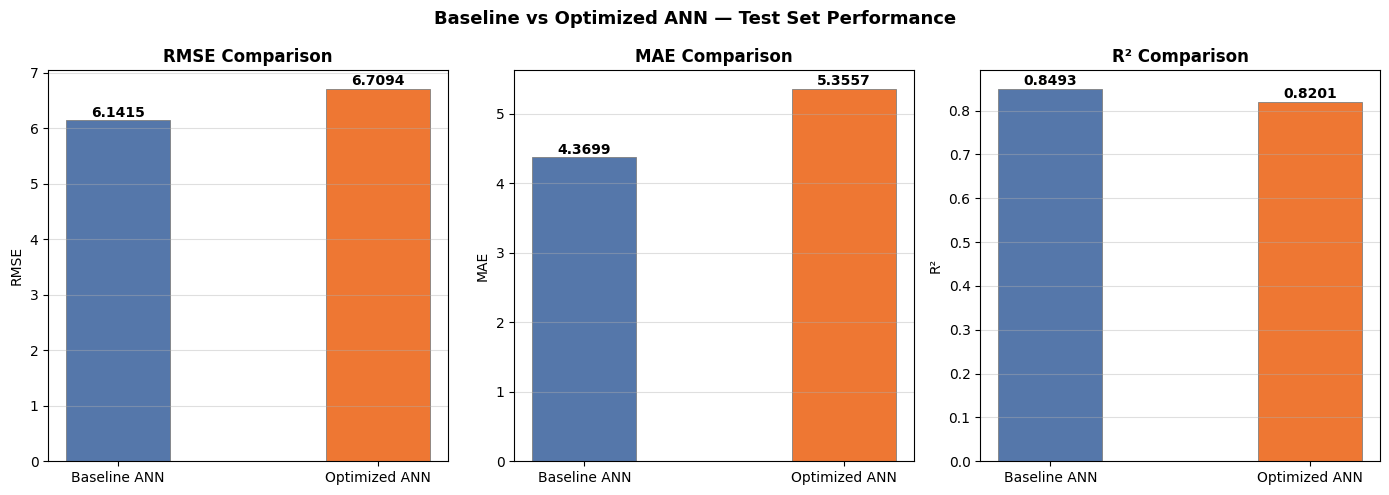

In [36]:
# Baseline vs Final comparison
metrics = ['RMSE', 'MAE', 'R²']
baseline_vals = [b_rmse_ts, b_mae_ts, b_r2_ts]
final_vals    = [f_rmse_ts, f_mae_ts, f_r2_ts]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (metric, bv, fv) in enumerate(zip(metrics, baseline_vals, final_vals)):
    bars = axes[i].bar(['Baseline ANN', 'Optimized ANN'], [bv, fv],
                       color=['#5577AA', '#EE7733'], edgecolor='grey', linewidth=0.6, width=0.4)
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, [bv, fv]):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                     f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Baseline vs Optimized ANN — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Improvement summary
rmse_imp = (b_rmse_ts - f_rmse_ts) / b_rmse_ts * 100
mae_imp  = (b_mae_ts  - f_mae_ts)  / b_mae_ts  * 100
r2_imp   = (f_r2_ts   - b_r2_ts)   / b_r2_ts   * 100

print("IMPROVEMENT OVER BASELINE:")
print(f" RMSE reduction : {rmse_imp:+.2f}%   ({b_rmse_ts:.4f} → {f_rmse_ts:.4f})")
print(f" MAE  reduction : {mae_imp:+.2f}%   ({b_mae_ts:.4f} → {f_mae_ts:.4f})")
print(f" R²   increase  : {r2_imp:+.2f}%   ({b_r2_ts:.4f} → {f_r2_ts:.4f})")

IMPROVEMENT OVER BASELINE:
 RMSE reduction : -9.25%   (6.1415 → 6.7094)
 MAE  reduction : -22.56%   (4.3699 → 5.3557)
 R²   increase  : -3.43%   (0.8493 → 0.8201)


In [38]:
# Final Model Architecture Summary
print("FINAL MODEL SUMMARY:")
summary = {
    'Dataset':            '1030 samples, 8 input features',
    'Train/Val/Test':     '70% / 15% / 15%',
    'Preprocessing':      'StandardScaler (zero mean, unit variance)',
    'Architecture':       '8→128→64→64→32→1 with BN & Dropout',
    'Activation':         'ReLU (hidden) + Linear (output)',
    'Regularization':     'L2 (1e-4) + Dropout (0.2, 0.1)',
    'Optimizer':          'Adam',
    'LR Schedule':        'Cosine Annealing (initial LR = 1e-3)',
    'Batch Size':         '16',
    'Early Stopping':     'patience=40, monitor=val_loss',
    'Test RMSE':          f'{f_rmse_ts:.4f} MPa',
    'Test MAE':           f'{f_mae_ts:.4f} MPa',
    'Test R²':            f'{f_r2_ts:.4f}',
}

for k, v in summary.items():
    print(f"  {k:<22}: {v}")
print("════════════════════════════════════════════════════")

FINAL MODEL SUMMARY:
  Dataset               : 1030 samples, 8 input features
  Train/Val/Test        : 70% / 15% / 15%
  Preprocessing         : StandardScaler (zero mean, unit variance)
  Architecture          : 8→128→64→64→32→1 with BN & Dropout
  Activation            : ReLU (hidden) + Linear (output)
  Regularization        : L2 (1e-4) + Dropout (0.2, 0.1)
  Optimizer             : Adam
  LR Schedule           : Cosine Annealing (initial LR = 1e-3)
  Batch Size            : 16
  Early Stopping        : patience=40, monitor=val_loss
  Test RMSE             : 6.7094 MPa
  Test MAE              : 5.3557 MPa
  Test R²               : 0.8201
════════════════════════════════════════════════════
